# Do unsupervised embeddings of the raw snapshots see the same transition?

This notebook produces `Plots/Fig_E_clustering.pdf` (Appendix E, low-dimensional
embeddings of the experimental snapshots) and the silhouette scores and transition
intervals quoted in its accompanying table.

### The question

Unlike learning by confusion and the prediction-divergence method, covered in the
companion `FiguresApp_E.ipynb`, this comparison method never trains TetrisCNN at all.
It projects the raw experimental snapshots into a low-dimensional embedding with PCA
(a linear projection onto directions of maximal variance) and UMAP (a nonlinear
embedding that preserves local neighborhood structure), clusters that embedding with
$k$-means, and assigns each acquisition time the majority cluster of its snapshots.
The transition is placed where that majority assignment first changes. Agreement
between this purely geometric method and the two model-based ones is evidence that
the detected transition is a property of the data, not an artifact of TetrisCNN's
architecture or training.

Layout: one row of four panels, (a) Ising PCA (three components, since two are not
enough to isolate the earliest snapshots), (b) Ising UMAP (two components), (c) XY PCA
(two components), (d) XY UMAP (two components), all colored by acquisition time.

### What it reads

Two dataset folders under `Plots_data/App_E_data/clustering/`, `Ising` and `XY`, each holding
only the `config.json` of a saved `partition` run. No trained network is needed here;
`_load_snapshots` rebuilds the validation split directly from the raw data via
`create_datasets` and flattens it, so the embeddings below are of the snapshots
themselves.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.utils import AttrDict, load_json
from tetriscnn.datasets import create_datasets

from tetriscnn.colors import COLORS

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import umap

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Loading snapshots and building embeddings

`_load_config_from_folder` is the same stride-compatibility loader used throughout
these notebooks. `_load_snapshots` uses it only to reconstruct the validation split
via `create_datasets`, then flattens each snapshot into a single feature vector and
returns it alongside its acquisition time; no trained TetrisCNN weights are loaded
for this figure. `_embed` wraps PCA and UMAP with the settings used throughout the
paper (in particular UMAP's `n_neighbors=250`, `min_dist=0`, cosine metric).
`_cluster_summary` runs $k$-means on an embedding, reports its silhouette score, and
walks the acquisition times in order to find where the majority cluster first
changes, which is the clustering estimate of the transition.


In [2]:
def _load_config_from_folder(seed_folder: Path) -> AttrDict:
    cfg_path = seed_folder / "config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No config.json found in {seed_folder}")
    cf = AttrDict()
    cf.update(load_json(str(seed_folder), "config.json"))
    for k in range(len(cf.kernels)):          # stride compatibility fix
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)
    cf.logdir = str(seed_folder)
    return cf

In [3]:
def _load_snapshots(load_path: Path):
    """Return the flattened validation snapshots and their acquisition times (in ns)."""
    cf = _load_config_from_folder(load_path)
    cf.seed_folder = str(load_path)
    cf.return_all_data = False
    _, val_dataset = create_datasets(cf)

    loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False,
                        num_workers=0, pin_memory=False)
    snapshots = np.concatenate([x.detach().cpu().numpy() for x, _ in loader], axis=0)
    snapshots = snapshots.reshape(snapshots.shape[0], -1)

    times = val_dataset.times.detach().cpu().numpy()
    return snapshots, times

In [4]:
def _embed(snapshots, n_components, which):
    """PCA or UMAP embedding of the flattened snapshots, with the settings used in the paper."""
    if which == "pca":
        reducer = PCA(n_components=n_components, random_state=2137)
    elif which == "umap":
        reducer = umap.UMAP(n_components=n_components, n_neighbors=250, min_dist=0.0,
                            metric="cosine", random_state=2137, n_jobs=1)
    else:
        raise ValueError("Unsupported reducer")
    return reducer.fit_transform(snapshots)

In [5]:
def _cluster_summary(times, embedding, n_clusters, name=""):
    """Silhouette score and the acquisition times bracketing the end of the initial cluster."""
    labels = KMeans(n_clusters=n_clusters, n_init=50, random_state=2137,
                    max_iter=2500).fit_predict(embedding)
    sil = silhouette_score(embedding, labels) if len(np.unique(labels)) > 1 else np.nan

    unique_times = np.unique(times)
    dominant = []
    for t in unique_times:
        counts = np.bincount(labels[times == t].astype(int), minlength=n_clusters)
        dominant.append((int(np.argmax(counts)), counts.max() / counts.sum()))

    boundary = None
    for i in range(1, len(unique_times)):
        if dominant[i][0] != dominant[0][0]:
            boundary = (unique_times[i - 1], unique_times[i])
            break

    print(f"[{name}] k={n_clusters} -> silhouette {sil:.4f}")
    for t, (lab, frac) in zip(unique_times, dominant):
        print(f"    t = {t / 1e3:.3f} us -> cluster {lab} (fraction {frac:.3f})")
    if boundary is None:
        print("    initial cluster not isolated")
    else:
        print(f"    initial cluster ends between {boundary[0] / 1e3:.3f} and {boundary[1] / 1e3:.3f} us")
    return sil, boundary

### Ising

Only the recorded configuration of the Ising `partition` run is used here; the raw
validation snapshots it points to are rebuilt directly by `_load_snapshots`.


In [6]:
# Ising `partition` run config (only config.json is needed -- snapshots are
# rebuilt from data/ via create_datasets). Copied from logs/ -- see Plots_data/App_E_data/.
basepath_Ising = Path("Plots_data/App_E_data/clustering/Ising")

snapshots_Ising, times_Ising = _load_snapshots(basepath_Ising)
print(snapshots_Ising.shape, np.unique(times_Ising) / 1e3)


 [LbC] CREATING DATASET: partition 3/27, threshold=1100.0000, total 20895 samples.

[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] LBC class distribution: class 0=2140, class 1=18755
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples


times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])


(6282, 64) [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4 3.6 3.8 4.
 4.2 4.4 4.6 4.8 5.  5.2 5.4 5.6 5.8 6. ]


In [7]:
emb_pca_Ising  = _embed(snapshots_Ising, 3, "pca")
emb_umap_Ising = _embed(snapshots_Ising, 2, "umap")

### XY

The same loading step, repeated for the XY dataset.


In [8]:
# XY (X+Z) `partition` run config.
basepath_XY = Path("Plots_data/App_E_data/clustering/XY")

snapshots_XY, times_XY = _load_snapshots(basepath_XY)
print(snapshots_XY.shape, np.unique(times_XY) / 1e3)


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])


times shape: 4347, labels shape: torch.Size([4347])


(4347, 84) [0.   0.25 0.5  0.75 1.   1.25 1.5  1.75 2.   2.5  3.   4.   6.  ]


In [9]:
emb_pca_XY  = _embed(snapshots_XY, 2, "pca")
emb_umap_XY = _embed(snapshots_XY, 2, "umap")

## Drawing Fig. E_clustering

Each panel scatters one embedding, colored by acquisition time on a shared colorbar.
Points are drawn in a randomly shuffled order (`_shuffled`) so that no acquisition
time is systematically plotted on top of another, which would otherwise bias the
visual impression of cluster separation. The Ising PCA panel (a) needs three
components and is drawn in 3D: with only two, the earliest-time cluster is not
cleanly separated from the rest of the sweep, which is itself informative about how
much of the snapshot variance the early-time signal occupies. The remaining three
panels embed in two components, which is already enough to isolate that same
early-time group.


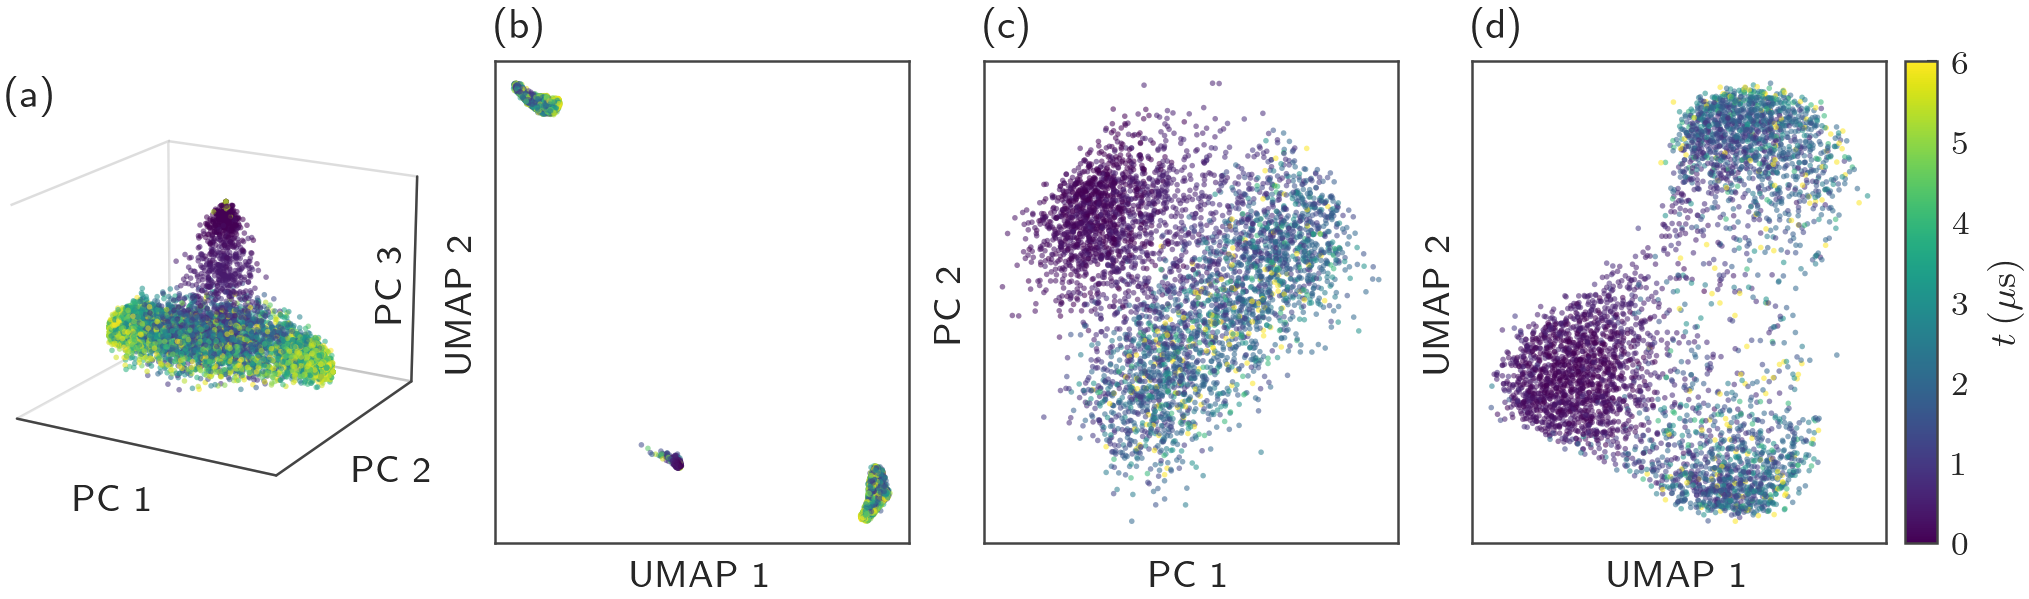

In [10]:
plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

CMAP = "viridis"
MARKER_SIZE = 1.8
MARKER_ALPHA = 0.55

fig = plt.figure(figsize=(DOUBLE_WIDTH, 0.30 * DOUBLE_WIDTH))

ax_a = fig.add_subplot(1, 4, 1, projection="3d")
ax_b = fig.add_subplot(1, 4, 2)
ax_c = fig.add_subplot(1, 4, 3)
ax_d = fig.add_subplot(1, 4, 4)


def _strip_ticks(ax, three_d=False):
    """The embedding coordinates carry no units, so only the axis names are kept."""
    ax.set_xticks([]); ax.set_yticks([])
    if three_d:
        ax.set_zticks([])
        ax.grid(False)
        for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
            axis.pane.set_facecolor("white")
            axis.pane.set_edgecolor(COLORS["gray"])
            axis.pane.set_alpha(0.25)


def _shuffled(times, seed=2137):
    """Random draw order, so no acquisition time is systematically drawn over another."""
    return np.random.default_rng(seed).permutation(times.shape[0])


# (a) Ising, PCA, three components
order = _shuffled(times_Ising)
ax_a.scatter(emb_pca_Ising[order, 0], emb_pca_Ising[order, 1], emb_pca_Ising[order, 2],
             c=times_Ising[order] / 1e3, cmap=CMAP, s=MARKER_SIZE, alpha=MARKER_ALPHA,
             linewidths=0, depthshade=False)
ax_a.set_xlabel("PC 1", labelpad=-12)
ax_a.set_ylabel("PC 2", labelpad=-12)
ax_a.set_zlabel("PC 3", labelpad=-24, rotation=90)
ax_a.view_init(elev=18, azim=-60)
ax_a.set_box_aspect(None, zoom=1.1)
_strip_ticks(ax_a, three_d=True)
ax_a.text2D(0.0, 1.05, "(a)", transform=ax_a.transAxes, va="top", size=10)

# (b) Ising, UMAP, two components
ax_b.scatter(emb_umap_Ising[order, 0], emb_umap_Ising[order, 1],
             c=times_Ising[order] / 1e3, cmap=CMAP, s=MARKER_SIZE, alpha=MARKER_ALPHA,
             linewidths=0)
ax_b.set_xlabel("UMAP 1"); ax_b.set_ylabel("UMAP 2")
_strip_ticks(ax_b)
ax_b.set_title("(b)", loc="left")

# (c) XY, PCA, two components
order = _shuffled(times_XY)
ax_c.scatter(emb_pca_XY[order, 0], emb_pca_XY[order, 1],
             c=times_XY[order] / 1e3, cmap=CMAP, s=MARKER_SIZE, alpha=MARKER_ALPHA,
             linewidths=0)
ax_c.set_xlabel("PC 1"); ax_c.set_ylabel("PC 2")
_strip_ticks(ax_c)
ax_c.set_title("(c)", loc="left")

# (d) XY, UMAP, two components
sc = ax_d.scatter(emb_umap_XY[order, 0], emb_umap_XY[order, 1],
                  c=times_XY[order] / 1e3, cmap=CMAP, s=MARKER_SIZE, alpha=MARKER_ALPHA,
                  linewidths=0)
ax_d.set_xlabel("UMAP 1"); ax_d.set_ylabel("UMAP 2")
_strip_ticks(ax_d)
ax_d.set_title("(d)", loc="left")

cbar = fig.colorbar(sc, ax=[ax_a, ax_b, ax_c, ax_d], fraction=0.018, pad=0.01, aspect=15)
cbar.set_label(r"$t\,(\mu\mathrm{s})$")
cbar.solids.set_alpha(1.0)

fig.savefig("Plots/Fig_E_clustering.pdf")


## Numbers quoted in the Appendix E table

The cell below reproduces every entry of the clustering table: for each
(dataset, reducer) pair it prints the silhouette score of the $k$-means clustering
used above and the pair of acquisition times bracketing where the majority cluster
first changes. The expected values are silhouette scores of 0.93 (Ising, UMAP), 0.48
(Ising, PCA), 0.62 (XY, UMAP), and 0.51 (XY, PCA), with transition intervals of
[1.0, 1.2] µs for Ising and [0.5, 0.75] µs for XY in every case, agreeing with the
learning-by-confusion and prediction-divergence estimates of the companion notebook.


In [11]:
_cluster_summary(times_Ising, emb_umap_Ising, 3, name="Ising UMAP (2 comp.)")
_cluster_summary(times_Ising, emb_pca_Ising, 4, name="Ising PCA (3 comp.)")
_cluster_summary(times_XY, emb_umap_XY, 3, name="XY UMAP (2 comp.)")
_cluster_summary(times_XY, emb_pca_XY, 3, name="XY PCA (2 comp.)")

[Ising UMAP (2 comp.)] k=3 -> silhouette 0.9331
    t = 0.600 us -> cluster 0 (fraction 1.000)
    t = 0.800 us -> cluster 0 (fraction 1.000)
    t = 1.000 us -> cluster 0 (fraction 1.000)
    t = 1.200 us -> cluster 2 (fraction 0.389)
    t = 1.400 us -> cluster 2 (fraction 0.549)
    t = 1.600 us -> cluster 2 (fraction 0.491)
    t = 1.800 us -> cluster 2 (fraction 0.545)
    t = 2.000 us -> cluster 1 (fraction 0.495)
    t = 2.200 us -> cluster 2 (fraction 0.544)
    t = 2.400 us -> cluster 1 (fraction 0.505)
    t = 2.600 us -> cluster 2 (fraction 0.537)
    t = 2.800 us -> cluster 1 (fraction 0.527)
    t = 3.000 us -> cluster 1 (fraction 0.511)
    t = 3.200 us -> cluster 1 (fraction 0.512)
    t = 3.400 us -> cluster 2 (fraction 0.499)
    t = 3.600 us -> cluster 1 (fraction 0.561)
    t = 3.800 us -> cluster 1 (fraction 0.545)
    t = 4.000 us -> cluster 1 (fraction 0.508)
    t = 4.200 us -> cluster 2 (fraction 0.528)
    t = 4.400 us -> cluster 1 (fraction 0.530)
    t = 4.60

[Ising PCA (3 comp.)] k=4 -> silhouette 0.4778
    t = 0.600 us -> cluster 3 (fraction 1.000)
    t = 0.800 us -> cluster 3 (fraction 1.000)
    t = 1.000 us -> cluster 3 (fraction 0.908)
    t = 1.200 us -> cluster 2 (fraction 0.833)
    t = 1.400 us -> cluster 2 (fraction 0.884)
    t = 1.600 us -> cluster 2 (fraction 0.667)
    t = 1.800 us -> cluster 2 (fraction 0.737)
    t = 2.000 us -> cluster 2 (fraction 0.564)
    t = 2.200 us -> cluster 2 (fraction 0.566)
    t = 2.400 us -> cluster 1 (fraction 0.412)
    t = 2.600 us -> cluster 2 (fraction 0.426)
    t = 2.800 us -> cluster 1 (fraction 0.391)
    t = 3.000 us -> cluster 1 (fraction 0.405)
    t = 3.200 us -> cluster 1 (fraction 0.405)
    t = 3.400 us -> cluster 1 (fraction 0.408)
    t = 3.600 us -> cluster 1 (fraction 0.463)
    t = 3.800 us -> cluster 1 (fraction 0.455)
    t = 4.000 us -> cluster 1 (fraction 0.466)
    t = 4.200 us -> cluster 0 (fraction 0.407)
    t = 4.400 us -> cluster 1 (fraction 0.470)
    t = 4.600

[XY PCA (2 comp.)] k=3 -> silhouette 0.5049
    t = 0.000 us -> cluster 2 (fraction 0.994)
    t = 0.250 us -> cluster 2 (fraction 0.987)
    t = 0.500 us -> cluster 2 (fraction 0.837)
    t = 0.750 us -> cluster 0 (fraction 0.511)
    t = 1.000 us -> cluster 1 (fraction 0.500)
    t = 1.250 us -> cluster 0 (fraction 0.535)
    t = 1.500 us -> cluster 0 (fraction 0.542)
    t = 1.750 us -> cluster 0 (fraction 0.557)
    t = 2.000 us -> cluster 0 (fraction 0.545)
    t = 2.500 us -> cluster 1 (fraction 0.556)
    t = 3.000 us -> cluster 0 (fraction 0.548)
    t = 4.000 us -> cluster 0 (fraction 0.509)
    t = 6.000 us -> cluster 1 (fraction 0.561)
    initial cluster ends between 0.500 and 0.750 us


(0.5049484372138977, (np.float32(500.0), np.float32(750.0)))

The cell below is a diagnostic aside: it recomputes the same embeddings colored by
$k$-means cluster label rather than acquisition time, producing an alternative figure
(`Fig_E_clustering_by_cluster.pdf`) that is not included in the manuscript. Left
commented out and kept for reference.


In [12]:
# # Recompute the cluster assignments using the cluster counts from the previous cell.
# labels_umap_Ising = KMeans(
#     n_clusters=3, n_init=50, random_state=2137, max_iter=2500
# ).fit_predict(emb_umap_Ising)

# labels_pca_Ising = KMeans(
#     n_clusters=4, n_init=50, random_state=2137, max_iter=2500
# ).fit_predict(emb_pca_Ising)

# labels_umap_XY = KMeans(
#     n_clusters=3, n_init=50, random_state=2137, max_iter=2500
# ).fit_predict(emb_umap_XY)

# labels_pca_XY = KMeans(
#     n_clusters=3, n_init=50, random_state=2137, max_iter=2500
# ).fit_predict(emb_pca_XY)

# cluster_cmap = plt.get_cmap("tab10")

# fig_clusters = plt.figure(figsize=(DOUBLE_WIDTH, 0.30 * DOUBLE_WIDTH))

# ax_a = fig_clusters.add_subplot(1, 4, 1, projection="3d")
# ax_b = fig_clusters.add_subplot(1, 4, 2)
# ax_c = fig_clusters.add_subplot(1, 4, 3)
# ax_d = fig_clusters.add_subplot(1, 4, 4)

# order_Ising = _shuffled(times_Ising)
# order_XY = _shuffled(times_XY)

# # (a) Ising PCA
# ax_a.scatter(
#     emb_pca_Ising[order_Ising, 0],
#     emb_pca_Ising[order_Ising, 1],
#     emb_pca_Ising[order_Ising, 2],
#     c=labels_pca_Ising[order_Ising],
#     cmap=cluster_cmap,
#     vmin=0,
#     vmax=3,
#     s=MARKER_SIZE,
#     alpha=MARKER_ALPHA,
#     linewidths=0,
#     depthshade=False,
# )
# ax_a.set_xlabel("PC 1", labelpad=-12)
# ax_a.set_ylabel("PC 2", labelpad=-12)
# ax_a.set_zlabel("PC 3", labelpad=-24)
# ax_a.view_init(elev=18, azim=-60)
# ax_a.set_box_aspect(None, zoom=1.1)
# _strip_ticks(ax_a, three_d=True)
# ax_a.text2D(0.0, 1.05, "(a)", transform=ax_a.transAxes, va="top", size=10)

# # (b) Ising UMAP
# ax_b.scatter(
#     emb_umap_Ising[order_Ising, 0],
#     emb_umap_Ising[order_Ising, 1],
#     c=labels_umap_Ising[order_Ising],
#     cmap=cluster_cmap,
#     vmin=0,
#     vmax=3,
#     s=MARKER_SIZE,
#     alpha=MARKER_ALPHA,
#     linewidths=0,
# )
# ax_b.set_xlabel("UMAP 1")
# ax_b.set_ylabel("UMAP 2")
# _strip_ticks(ax_b)
# ax_b.set_title("(b)", loc="left")

# # (c) XY PCA
# ax_c.scatter(
#     emb_pca_XY[order_XY, 0],
#     emb_pca_XY[order_XY, 1],
#     c=labels_pca_XY[order_XY],
#     cmap=cluster_cmap,
#     vmin=0,
#     vmax=3,
#     s=MARKER_SIZE,
#     alpha=MARKER_ALPHA,
#     linewidths=0,
# )
# ax_c.set_xlabel("PC 1")
# ax_c.set_ylabel("PC 2")
# _strip_ticks(ax_c)
# ax_c.set_title("(c)", loc="left")

# # (d) XY UMAP
# sc_clusters = ax_d.scatter(
#     emb_umap_XY[order_XY, 0],
#     emb_umap_XY[order_XY, 1],
#     c=labels_umap_XY[order_XY],
#     cmap=cluster_cmap,
#     vmin=0,
#     vmax=3,
#     s=MARKER_SIZE,
#     alpha=MARKER_ALPHA,
#     linewidths=0,
# )
# ax_d.set_xlabel("UMAP 1")
# ax_d.set_ylabel("UMAP 2")
# _strip_ticks(ax_d)
# ax_d.set_title("(d)", loc="left")

# cbar_clusters = fig_clusters.colorbar(
#     sc_clusters,
#     ax=[ax_a, ax_b, ax_c, ax_d],
#     fraction=0.018,
#     pad=0.01,
#     aspect=15,
#     ticks=[0, 1, 2, 3],
# )
# cbar_clusters.set_label("Cluster")
# cbar_clusters.solids.set_alpha(1.0)

# fig_clusters.savefig("Plots/Fig_E_clustering_by_cluster.pdf")